In [25]:
%load_ext autoreload
%autoreload 2

import parse_data

#sds = [0.05, 0.005, 0.01]
sds = [0.01, 0.02, 0.04]
uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
wanted = [0.01]
uds.sort(), sds.sort()
tskit = True

popsize = 2000

# Ran into some comma issues before
# It's caused by having commas in the HPC, so be sure remove them. But this method also removes all the commas that are in names of the important files.

nes = []
for sd in sds:
    # We are removing any of the commas in the name (if they are there).
    parse_data.remove_commas_recursively(f"/Users/cameronliu/Desktop/Research/Datasets/Current/sd-{sd}-exp-reformatted-tskit")

    # We are calculating the Ne's that are present in each of the sd files. 
    inner_nes = parse_data.get_all_nes(f"/Users/cameronliu/Desktop/Research/Datasets/sd-{sd}-exp-reformatted-tskit", uds, sd, tskit, popsize)
    # This writes all the information of inner_nes into a file. This is for future-proofing, not having to calculate Ne from each file each time - saves lots of computational power
    final_message = parse_data.write_all_nes(inner_nes)

if final_message: print("Successfully parsed data for files {sds}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Calculating Coalescent Ne: 2009.189778433079 using sd: 0.01, ud: 0.01
Calculating Coalescent Ne: 2024.333939747425 using sd: 0.01, ud: 0.02
Calculating Coalescent Ne: 1985.179959249927 using sd: 0.01, ud: 0.03
Calculating Coalescent Ne: 2006.7210263923737 using sd: 0.01, ud: 0.05
Calculating Coalescent Ne: 1971.030446940875 using sd: 0.01, ud: 0.075
Calculating Coalescent Ne: 1981.3623337154936 using sd: 0.01, ud: 0.1
Calculating Coalescent Ne: 1973.550401477554 using sd: 0.01, ud: 0.2
Calculating Coalescent Ne: 1922.8555469439236 using sd: 0.01, ud: 0.35
Calculating Coalescent Ne: 1909.7338037625825 using sd: 0.01, ud: 0.5
Calculating Coalescent Ne: 1908.201000882852 using sd: 0.01, ud: 0.75
Calculating Coalescent Ne: 1854.1372252125088 using sd: 0.01, ud: 1
Calculating Coalescent Ne: 1791.4242582176753 using sd: 0.01, ud: 1.25
Calculating Coalescent Ne: 1786.5879161715795 using sd: 0.01, ud: 1.5
C

In [34]:
# Cell to calculate all the information to parse the information from the file 
# Need to develop a system to create a new file that's easier and faster to read the data from

import matplotlib.pyplot as plt
import numpy as np    
from scipy import stats
import statistics
import math

# This is my own .py file, with methods that I have created myself.
import parse_data

pop_size = 2000
burnin = 4*pop_size

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort()
exp = True

# These are important to remember
# parse_exp([uds], sd, BURNIN, COMMA)


global_data = []


nes = []
for sd in sds: 
    #tskit = True if sd == 0.0025 else False
    if exp: 
        data, timesteps = parse_data.parse_exponential(uds, sd, tskit)
    else: 
        data, timesteps = parse_data.parse_normal_from_exp(uds, sd, tskit)

    sliced_data, sliced_timesteps = parse_data.slice_data(data, timesteps, burnin)
    nes.append(parse_data.parse_all_nes(sd, popsize))
    global_data.append((sliced_data, sliced_timesteps))

# sliced_data's format = (sd, (ud, f. sel. deaths))


------------------------------------------------------------------
Successfully Parsed Exponential Data for file SD = 0.01, UD = 0.01
------------------------------------------------------------------

------------------------------------------------------------------
Successfully Parsed Exponential Data for file SD = 0.01, UD = 0.02
------------------------------------------------------------------

------------------------------------------------------------------
Successfully Parsed Exponential Data for file SD = 0.01, UD = 0.03
------------------------------------------------------------------

------------------------------------------------------------------
Successfully Parsed Exponential Data for file SD = 0.01, UD = 0.05
------------------------------------------------------------------

------------------------------------------------------------------
Successfully Parsed Exponential Data for file SD = 0.01, UD = 0.075
---------------------------------------------------------

-0.00985731380847632
-0.020106593659720673
-0.030977023679323423
-0.051283580994189615
-0.07160956701283783
-0.08742561762050327
-0.14162325629487738
-0.2117096717023903
-0.26007678922251265
-0.35859981417293274
-0.4267461336751759
-0.5280357501255972
-0.61308419918306
-0.7790922283554964
-1.5961474732317793
-3.67890601854939
-12.292483585505739
-0.00985784614348284
-0.020614003151153026
-0.029535855244254616
-0.04963660717891627
-0.07394155578548434
-0.09820400839254417
-0.17095649921136924
-0.2810012549449128
-0.36022124228651187
-0.5115651734264826
-0.6475844267544413
-0.8365177727545039
-0.9141361290700416
-1.2276897119681087
(1.6826996185062693+4.2073164848342675j)
-6.430185329474823
(2.7277288923037544+3.6590029528828016j)
[Complex Value Detected] Index 14, Value: (1.6826996185062693+4.2073164848342675j)
[Complex Value Detected] Index 16, Value: (2.7277288923037544+3.6590029528828016j)


/Users/cameronliu/.venvs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/cameronliu/.venvs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


-0.009981594248398062
-0.020181477743909104
-0.030086602775247995
-0.04952765561142014
-0.07408872950796708
-0.09743295938533647
-0.18597897421390774
-0.3011862307377826
-0.4553226565638908
-0.6785347943464071
-1.0129631836499189
-1.2988080246904579
-1.3830214471387037
-2.37625036247775
-11.96339399348274
-11.721678861945165
-3.0662157279208095


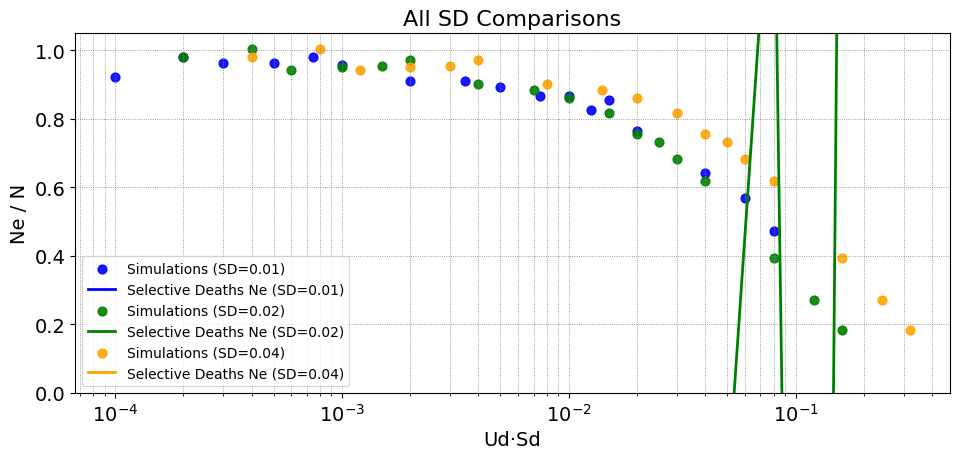

In [14]:
# Plotting Comparison Graphs - All on one Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud·Sd
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs

sd_colors = {
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange'
}



for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform(transformed_datasets)


    # Find SD value as float
    sd = float(sliced_data[0][0][3:])

    # Generate Ud·Sd array for THIS SD
    ud_sd_array = parse_data.generate_ud_sd(uds, sd)

    # Matheson's raw dataset (keep only y-values)
    matheson_dataset = parse_data.get_matheson_dataset(sd)
    y_matheson = [y for _, y in matheson_dataset]

    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in back_transformed_values]
    for value in y_back_transformed: 
        print(value)
    for i, y in enumerate(y_back_transformed):
        if isinstance(y, complex):
            print(f"[Complex Value Detected] Index {i}, Value: {y}")


    # Plot Matheson's dataset (points)
    plt.scatter(
        ud_sd_array, y_matheson,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Simulations (SD={sd})"
    )

    # Plot back-transformed values (line)
    plt.plot(
        ud_sd_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"Selective Deaths Ne (SD={sd})"
    )

plt.title('All SD Comparisons', fontsize=16)
plt.xlabel('Ud·Sd', fontsize=14)
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("/Users/cameronliu/Desktop/Research/Graphs/Comparison Graphs/Unexponentiated/all-sds-comparison-udsd.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Plotting Comparison Graphs - Ne Reproductive Rate, Matheson Ne, Divided by 2 (UNUSED)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud·Sd
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs
sd_colors = {
    0.01: 'blue',
    0.005: 'green',
    0.05: 'orange'
}

for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform_div_2(transformed_datasets)
    ne_reproductive_uds = parse_data.transform_nereproductive_rate(back_transformed_values)

    # Find SD value as float
    sd = float(sliced_data[0][0][3:])

    # Generate Ud·Sd array for THIS SD
    ud_sd_array = parse_data.generate_ud_sd(uds, sd)

    # Matheson's raw dataset (keep only y-values)
    matheson_dataset = parse_data.get_matheson_dataset(sd)
    y_matheson = [y for _, y in matheson_dataset]

    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in ne_reproductive_uds]

    # Plot Matheson's dataset (points)
    plt.scatter(
        ud_sd_array, y_matheson,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Simulations (SD={sd})"
    )

    # Plot back-transformed values (line)
    plt.plot(
        ud_sd_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"From Selective Deaths (SD={sd})"
    )

plt.title('All SD Comparisons, Ne-Reproductive Rate', fontsize=16)
plt.xlabel('Ud·Sd', fontsize=14)
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("/Users/cameronliu/Desktop/Research/Graphs/Comparison Graphs/Unexponentiated/matheson-ne-reproductive-all-sds-comparison-udsd.png", dpi=300, bbox_inches='tight')
plt.show()


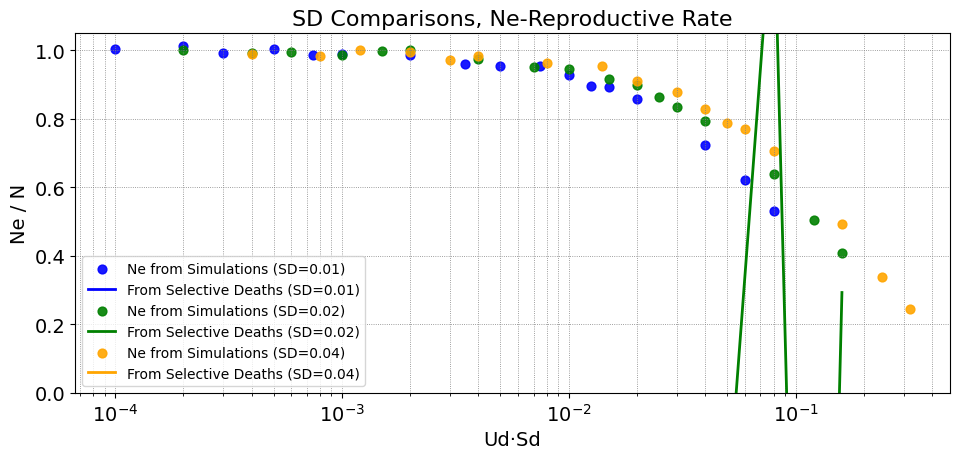

In [18]:
# Plotting Comparison Graphs - Ne Reproductive Rate, Our Ne
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud·Sd
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs
sd_colors = {
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange'
}

for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform(transformed_datasets)
    ne_reproductive_uds = parse_data.transform_nereproductive_rate(back_transformed_values)

    # Find SD value as float
    sd = float(sliced_data[0][0][3:])
    

    # Generate Ud·Sd array for THIS SD
    ud_sd_array = parse_data.generate_ud_sd(uds, sd)

    # Our Ne dataset (keep only y-values)
    our_ne_data = parse_data.parse_all_nes(sd, popsize)
    y_ne_data = []
    for outer, inner in our_ne_data: 
        y_ne_data.append(inner[1])
    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in ne_reproductive_uds]

    plt.scatter(
        ud_sd_array, y_ne_data,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Ne from Simulations (SD={sd})"
    )

    # Plot back-transformed values (line)
    plt.plot(
        ud_sd_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"From Selective Deaths (SD={sd})"
    )

plt.title('SD Comparisons, Ne-Reproductive Rate', fontsize=16)
plt.xlabel('Ud·Sd', fontsize=14)
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("/Users/cameronliu/Desktop/Research/Graphs/Comparison Graphs/Unexponentiated/our-ne-reproductive-all-sds-comparison-udsd.png", dpi=300, bbox_inches='tight')
plt.show()


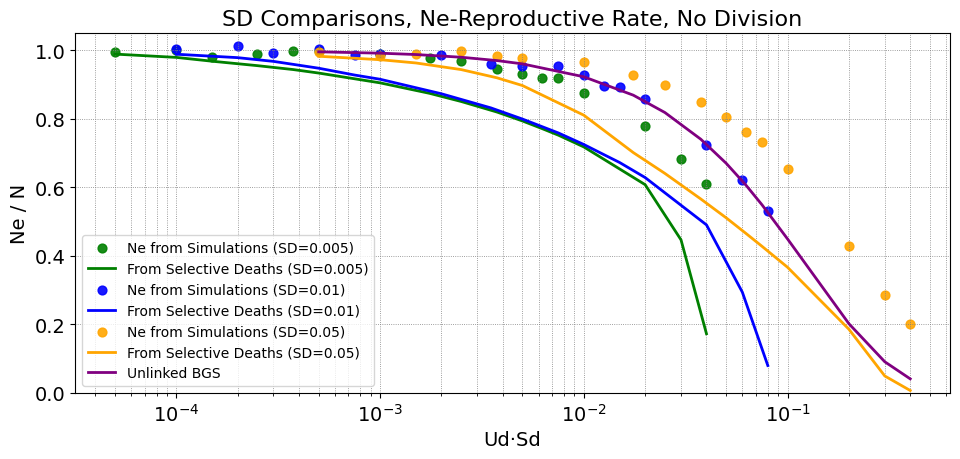

In [6]:
# Plotting Comparison Graphs - Ne Reproductive Rate, Our Ne, With Division
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud·Sd
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs
sd_colors = {
    0.01: 'blue',
    0.005: 'green',
    0.05: 'orange'
}

for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform(transformed_datasets)
    ne_reproductive_uds = parse_data.transform_nereproductive_rate(back_transformed_values)

    # Find SD value as float
    sd = float(sliced_data[0][0][3:])
    

    # Generate Ud·Sd array for THIS SD
    ud_sd_array = parse_data.generate_ud_sd(uds, sd)

    # Our Ne dataset (keep only y-values)
    our_ne_data = parse_data.parse_all_nes(sd, popsize)
    y_ne_data = []
    for outer, inner in our_ne_data: 
        y_ne_data.append(inner[1])

    # Matheson Unlinked Equation
    y_bgs = []
    matheson_bgs = parse_data.calculate_matheson_data(uds, sd, False)
    for ud, datapoint in matheson_bgs: 
        y_bgs.append(datapoint)

    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in ne_reproductive_uds]

    plt.scatter(
        ud_sd_array, y_ne_data,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Ne from Simulations (SD={sd})"
    )

    # Plot back-transformed values (line)
    plt.plot(
        ud_sd_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"From Selective Deaths (SD={sd})"
    )

# Plot unlinked BGS values (fixed purple color)
plt.plot(
    ud_sd_array, y_bgs,
    color="purple",
    linewidth=2,
    linestyle='-',
    label="Unlinked BGS"
)

plt.title('SD Comparisons, Ne-Reproductive Rate, No Division', fontsize=16)
plt.xlabel('Ud·Sd', fontsize=14)
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("/Users/cameronliu/Desktop/Research/Graphs/Comparison Graphs/Unexponentiated/bgs-ne-reproductive-all-sds-comparison-udsd.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# (UNUSED) Plotting Comparison Graphs - Ne Reproductive Rate, Our Ne, with Divison
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud·Sd
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs
sd_colors = {
    0.01: 'blue',
    0.005: 'green',
    0.05: 'orange'
}

for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform_div_2(transformed_datasets)
    ne_reproductive_uds = parse_data.transform_nereproductive_rate(back_transformed_values)

    # Find SD value as float
    sd = float(sliced_data[0][0][3:])
    

    # Generate Ud·Sd array for THIS SD
    ud_sd_array = parse_data.generate_ud_sd(uds, sd)

    # Our Ne dataset (keep only y-values)
    our_ne_data = parse_data.parse_all_nes(sd, popsize)
    y_ne_data = []
    for outer, inner in our_ne_data: 
        y_ne_data.append(inner[1])

    # Matheson Unlinked Equation
    y_bgs = []
    matheson_bgs = parse_data.calculate_matheson_data(uds, sd, False)
    for ud, datapoint in matheson_bgs: 
        y_bgs.append(datapoint)

    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in ne_reproductive_uds]

    plt.scatter(
        ud_sd_array, y_ne_data,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Ne from Simulations (SD={sd})"
    )

    # Plot back-transformed values (line)
    plt.plot(
        ud_sd_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"From Selective Deaths (SD={sd})"
    )

# Plot unlinked BGS values (fixed purple color)
plt.plot(
    ud_sd_array, y_bgs,
    color="purple",
    linewidth=2,
    linestyle='-',
    label="Unlinked BGS"
)

plt.title('SD Comparisons, Ne-Reproductive Rate, Division', fontsize=16)
plt.xlabel('Ud·Sd', fontsize=14)
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("/Users/cameronliu/Desktop/Research/Graphs/Comparison Graphs/Unexponentiated/bgs-ne-reproductive_div_2-all-sds-comparison-udsd.png", dpi=300, bbox_inches='tight')
plt.show()


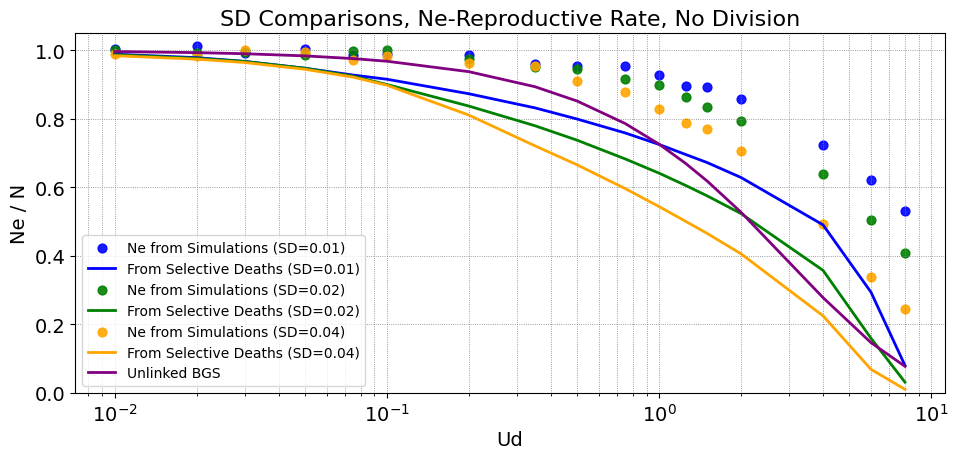

In [22]:
# Plotting Comparison Graphs - Ne Reproductive Rate, Our Ne, With Ud on X-axis
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs
sd_colors = {
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange'
}

for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform(transformed_datasets)
    ne_reproductive_uds = parse_data.transform_nereproductive_rate(back_transformed_values)

    # Find SD value as float
    sd = float(sliced_data[0][0][3:])
    
    # UD on x-axis instead of Y-axis
    ud_array = uds  

    # Our Ne dataset (keep only y-values)
    our_ne_data = parse_data.parse_all_nes(sd, popsize)
    y_ne_data = []
    for outer, inner in our_ne_data: 
        y_ne_data.append(inner[1])

    # Matheson Unlinked Equation
    y_bgs = []
    matheson_bgs = parse_data.calculate_matheson_data(uds, sd, False)
    for ud, datapoint in matheson_bgs: 
        y_bgs.append(datapoint)

    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in ne_reproductive_uds]


    # Plot simulation data
    plt.scatter(
        ud_array, y_ne_data,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Ne from Simulations (SD={sd})"
    )

    # Plot back-transformed values (line)
    plt.plot(
        ud_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"From Selective Deaths (SD={sd})"
    )

# Plot unlinked BGS values (fixed purple color)
plt.plot(
    ud_array, y_bgs,
    color="purple",
    linewidth=2,
    linestyle='-',
    label="Unlinked BGS"
)

plt.title('SD Comparisons, Ne-Reproductive Rate, No Division', fontsize=16)
plt.xlabel('Ud', fontsize=14)   # X-axis is Ud now
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig(
    "/Users/cameronliu/Desktop/Research/Graphs/Comparison Graphs/Unexponentiated/"

    "sd-comparisons-xud-yne.png",

    dpi=300, bbox_inches='tight'
)
plt.show()


******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.01
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.02
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.03
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.05
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.075
******************************************************************

*****************************

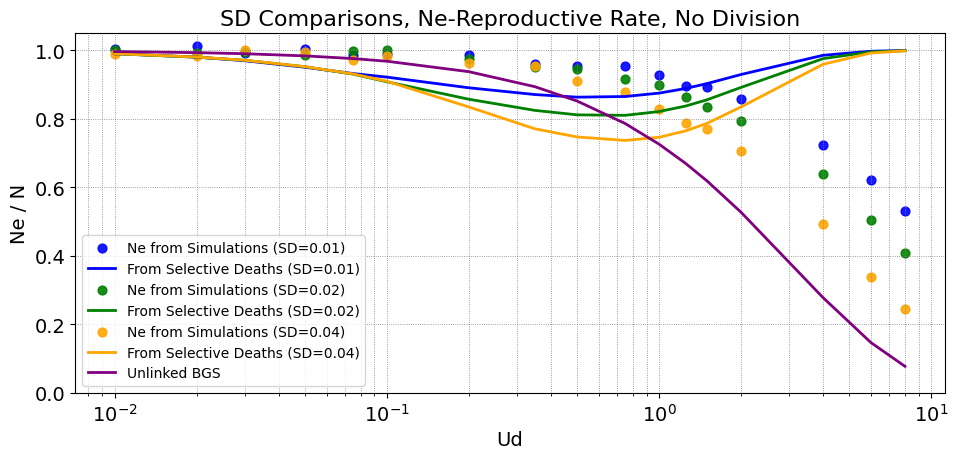

In [ ]:
# Plotting Comparison Graphs - Ne Reproductive Rate, Our Ne, With Ud on X-axis, Exponential
# Ulises and I were working on this, trying to bridge the gap on Selective Deaths and how it can help predict Ne a bit better. 
# We think the problem may be found whilst calculating birthrates in the simulation, as the rounding point errors when numbers get exponentially small, 
# can cause issues when computing small numbers. Realistically, it's something that the next person should get into. 

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs
sd_colors = {
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange'
}

for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform(transformed_datasets)
    ne_reproductive_uds = parse_data.transform_nereproductive_rate(back_transformed_values)

    # Find SD value as float
    sd = float(sliced_data[0][0][3:])
    
    # UD on x-axis instead of Y-axis
    ud_array = uds  

    # Our Ne dataset (keep only y-values)
    our_ne_data = parse_data.parse_all_nes(sd, popsize)
    y_ne_data = []
    for outer, inner in our_ne_data: 
        y_ne_data.append(inner[1])

    # Matheson Unlinked Equation
    y_bgs = []
    matheson_bgs = parse_data.calculate_matheson_data(uds, sd, False)
    for ud, datapoint in matheson_bgs: 
        y_bgs.append(datapoint)

    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in back_transformed_values]


    # Plot simulation data
    plt.scatter(
        ud_array, y_ne_data,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Ne from Simulations (SD={sd})"
    )

    # Plot back-transformed values (line)
    plt.plot(
        ud_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"From Selective Deaths (SD={sd})"
    )

# Plot unlinked BGS values (fixed purple color)
plt.plot(
    ud_array, y_bgs,
    color="purple",
    linewidth=2,
    linestyle='-',
    label="Unlinked BGS"
)

plt.title('SD Comparisons, Ne-Reproductive Rate, No Division', fontsize=16)
plt.xlabel('Ud', fontsize=14)   # X-axis is Ud now
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig(
    "/Users/cameronliu/Desktop/Research/Graphs/Comparison Graphs/Exponentiated/"

    "sd-comparisons-xud-yne.png",

    dpi=300, bbox_inches='tight'
)
plt.show()
